In [1]:
# Setup & Install dependencies

# "timm>=1.0.11"

!pip -q install kagglehub scikit-learn seaborn \
                grad-cam ptflops statsmodels scipy --upgrade

print("Installs complete.")

Installs complete.


In [2]:
!pip install -U \
torch \
torchvision \
timm \
pillow==11.0.0 \
rembg \
onnxruntime

  Using cached rembg-2.0.84-py3-none-any.whl.metadata (25 kB)
  Using cached numpy-2.5.3-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
INFO: pip is looking at multiple versions of rembg to determine which version is compatible with other requirements. This could take a while.
  Using cached rembg-2.0.83-py3-none-any.whl.metadata (25 kB)
  Using cached rembg-2.0.82-py3-none-any.whl.metadata (25 kB)
  Using cached rembg-2.0.81-py3-none-any.whl.metadata (25 kB)
  Using cached rembg-2.0.80-py3-none-any.whl.metadata (25 kB)
  Using cached rembg-2.0.79-py3-none-any.whl.metadata (23 kB)
  Using cached rembg-2.0.78-py3-none-any.whl.metadata (19 kB)
  Using cached rembg-2.0.77-py3-none-any.whl.metadata (18 kB)
INFO: pip is still looking at multiple versions of rembg to determine which version is compatible with other requirements. This could take a while.
  Using cached rembg-2.0.76-py3-none-any.whl.metadata (18 kB)
  Using cached rembg-2.0.75-py3-none-any.whl.me

In [3]:
# Imports, config, reproducibility

import os, time, shutil, random, warnings
import numpy as np, pandas as pd
import torch, torch.nn as nn, torch.nn.functional as F
import timm
import torchvision.models as tvmodels
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Dataset
from PIL import Image
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, classification_report, confusion_matrix, roc_curve, auc)
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt, seaborn as sns
warnings.filterwarnings("ignore")

from rembg import remove
import io

In [4]:
SEED = 42
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 12
LR = 3e-4
PATIENCE = 4
NUM_WORKERS = 2
IMG_EXT = (".jpg", ".jpeg", ".png", ".bmp")
SPLIT_ROOT = "/content/data_split"
WEIGHTS_DIR = "/content/weights"
os.makedirs(WEIGHTS_DIR, exist_ok=True)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

def set_seed(s=SEED):
    random.seed(s); np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)
set_seed()

RESULTS = {}

In [5]:
print("Device:", DEVICE, "| LR:", LR, type(LR).__name__)
if DEVICE == "cpu": print("WARNING: no GPU. Runtime -> Change runtime type -> T4 GPU.")

Device: cuda | LR: 0.0003 float


In [6]:
# Download dataset and auto-locate the class folders

import kagglehub

download_path = kagglehub.dataset_download("asdasdasasdas/garbage-classification")
EXPECTED = {"cardboard", "glass", "metal", "paper", "plastic", "trash"}

def find_dataset_root(base):
    best, best_score = None, -1
    for dirpath, dirnames, _ in os.walk(base):
        subs = []
        for d in dirnames:
            if d.startswith("."): continue
            p = os.path.join(dirpath, d)
            try:
                if any(f.lower().endswith(IMG_EXT) for f in os.listdir(p)): subs.append(d.lower())
            except (NotADirectoryError, PermissionError): pass
        if not subs: continue
        score = len(set(subs) & EXPECTED) * 100 + len(subs)
        if score > best_score: best, best_score = dirpath, score
    if best is None: raise RuntimeError(f"No class folders under {base}")
    return best

Using Colab cache for faster access to the 'garbage-classification' dataset.


In [7]:
DATA_ROOT = find_dataset_root(download_path)
CLASSES = sorted([d for d in os.listdir(DATA_ROOT)
                  if os.path.isdir(os.path.join(DATA_ROOT, d))
                  and any(f.lower().endswith(IMG_EXT) for f in os.listdir(os.path.join(DATA_ROOT, d)))])

NUM_CLASSES = len(CLASSES)

print("Image root:", DATA_ROOT)
print("Classes:", CLASSES)

Image root: /kaggle/input/garbage-classification/Garbage classification/Garbage classification
Classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [8]:
# class distribution

counts = {c: len([f for f in os.listdir(os.path.join(DATA_ROOT, c)) if f.lower().endswith(IMG_EXT)])
          for c in CLASSES}
print("Total:", sum(counts.values()))

Total: 2527


In [9]:
for c, n in counts.items(): print(f"  {c:12s} {n}")

  cardboard    403
  glass        501
  metal        410
  paper        594
  plastic      482
  trash        137


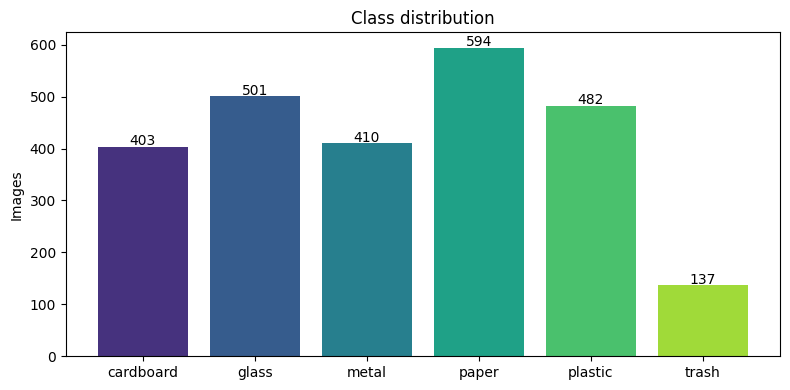

In [10]:
plt.figure(figsize=(8, 4))
plt.bar(counts.keys(), counts.values(), color=sns.color_palette("viridis", NUM_CLASSES))
plt.title("Class distribution"); plt.ylabel("Images")
for i, v in enumerate(counts.values()): plt.text(i, v + 3, str(v), ha="center")
plt.tight_layout(); plt.show()

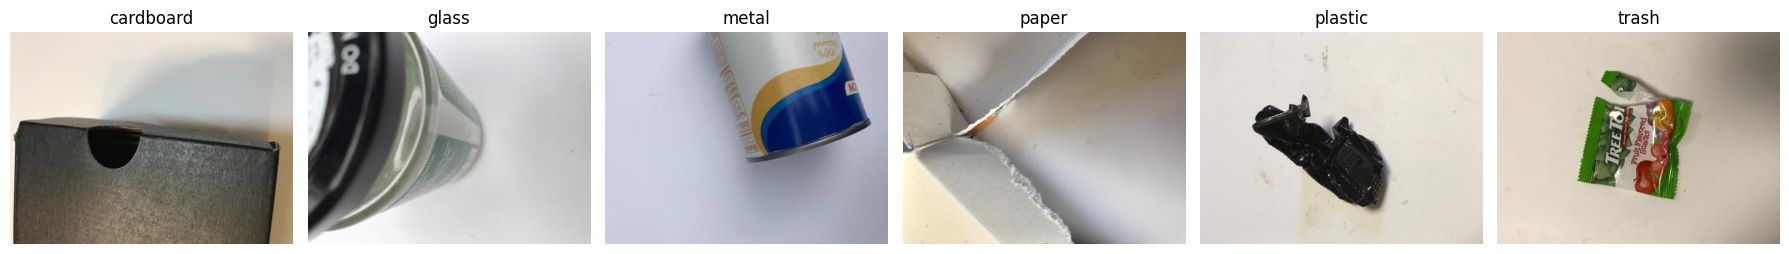

In [11]:
# Display sample images (one per class)

fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(3 * NUM_CLASSES, 3))

for ax, c in zip(np.ravel(axes), CLASSES):
    d = os.path.join(DATA_ROOT, c)
    f = next(f for f in os.listdir(d) if f.lower().endswith(IMG_EXT))
    ax.imshow(Image.open(os.path.join(d, f)).convert("RGB")); ax.set_title(c); ax.axis("off")

plt.tight_layout(); plt.show()

In [12]:
# Analyze image dimensions (sample up to 400 images for speed)

ws, hs = [], []
allp = [os.path.join(DATA_ROOT, c, f) for c in CLASSES
        for f in os.listdir(os.path.join(DATA_ROOT, c)) if f.lower().endswith(IMG_EXT)]
for p in random.sample(allp, min(400, len(allp))):
    try:
        with Image.open(p) as im: w, h = im.size; ws.append(w); hs.append(h)
    except Exception: pass

print(f"Width  min/med/max: {min(ws)}/{int(np.median(ws))}/{max(ws)}")
print(f"Height min/med/max: {min(hs)}/{int(np.median(hs))}/{max(hs)}")

Width  min/med/max: 512/512/512
Height min/med/max: 384/384/384


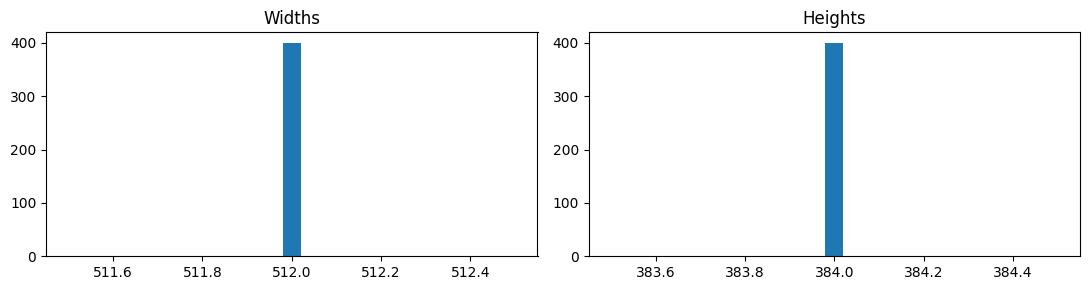

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3))
ax[0].hist(ws, bins=25); ax[0].set_title("Widths")
ax[1].hist(hs, bins=25); ax[1].set_title("Heights")
plt.tight_layout(); plt.show()

In [14]:
# Stratified 70/15/15 split copied into train/val/test folders

def build_split(seed=SEED):
    if os.path.exists(SPLIT_ROOT): shutil.rmtree(SPLIT_ROOT)
    paths, labels = [], []
    for c in CLASSES:
        d = os.path.join(DATA_ROOT, c)
        for f in os.listdir(d):
            if f.lower().endswith(IMG_EXT): paths.append(os.path.join(d, f)); labels.append(c)
    p_tr, p_tmp, y_tr, y_tmp = train_test_split(paths, labels, test_size=0.30, stratify=labels, random_state=seed)
    p_va, p_te, y_va, y_te = train_test_split(p_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=seed)
    for split, (ps, ys) in {"train": (p_tr, y_tr), "val": (p_va, y_va), "test": (p_te, y_te)}.items():
        for c in CLASSES: os.makedirs(os.path.join(SPLIT_ROOT, split, c), exist_ok=True)
        for src, c in zip(ps, ys):
            shutil.copy(src, os.path.join(SPLIT_ROOT, split, c, os.path.basename(src)))
    print("train/val/test:", len(p_tr), len(p_va), len(p_te))

In [15]:
build_split()

train/val/test: 1768 379 380


In [16]:
# Augmentation + dataloaders + class weights (processed-data pipeline)

MEAN, STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)), transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15), transforms.ColorJitter(0.2, 0.2, 0.2),
    transforms.ToTensor(), transforms.Normalize(MEAN, STD)])

eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)), transforms.ToTensor(), transforms.Normalize(MEAN, STD)])

train_ds = datasets.ImageFolder(os.path.join(SPLIT_ROOT, "train"), transform=train_tf)
val_ds   = datasets.ImageFolder(os.path.join(SPLIT_ROOT, "val"),   transform=eval_tf)
test_ds  = datasets.ImageFolder(os.path.join(SPLIT_ROOT, "test"),  transform=eval_tf)

assert train_ds.classes == CLASSES

train_loader = DataLoader(train_ds, BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

cnt = np.bincount([y for _, y in train_ds.samples], minlength=NUM_CLASSES).astype(float)

class_weights = torch.tensor(cnt.sum() / (NUM_CLASSES * cnt), dtype=torch.float32)

TEST_TRUE = np.array([y for _, y in test_ds.samples])

print("Class weights:", np.round(class_weights.numpy(), 2))

Class weights: [1.04 0.84 1.03 0.71 0.87 3.07]


In [17]:
# Model factory + shared train / evaluate / efficiency machinery

MODEL_REGISTRY = {
    "MobileNetV3-Large":  {"source": "timm", "names": ["mobilenetv3_large_100"]},
    "EfficientNet-Lite0": {"source": "timm", "names": ["tf_efficientnet_lite0", "efficientnet_lite0"]},
    "ShuffleNetV2":       {"source": "torchvision", "names": ["shufflenet_v2_x1_0"]},
    "GhostNet":           {"source": "timm", "names": ["ghostnet_100"]},
    "SqueezeNet":         {"source": "torchvision", "names": ["squeezenet1_1"]},
    "EfficientViT":       {"source": "timm", "names": ["efficientvit_b0", "efficientvit_b1",
                                                        "efficientvit_m1", "efficientvit_m0"]},
}

def build_model(spec, num_classes):
    if spec["source"] == "timm":
        err = None
        for n in spec["names"]:
            for pre in (True, False):
                try:
                    m = timm.create_model(n, pretrained=pre, num_classes=num_classes)
                    if not pre: print(f"  [warn] {n}: no pretrained weights, from scratch")
                    return m, n
                except Exception as e: err = e
        raise RuntimeError(f"Could not build {spec['names']}: {err}")
    n = spec["names"][0]
    if n == "shufflenet_v2_x1_0":
        m = tvmodels.shufflenet_v2_x1_0(weights="IMAGENET1K_V1")
        m.fc = nn.Linear(m.fc.in_features, num_classes)
    elif n == "squeezenet1_1":
        m = tvmodels.squeezenet1_1(weights="IMAGENET1K_V1")
        m.classifier[1] = nn.Conv2d(512, num_classes, 1); m.num_classes = num_classes
    return m, n

def _infer(model, loader):
    model.eval(); ys, ps, prob = [], [], []
    with torch.inference_mode():
        for x, y in loader:
            out = model(x.to(DEVICE)); sm = F.softmax(out, 1).cpu().numpy()
            ps.extend(out.argmax(1).cpu().numpy()); ys.extend(y.numpy()); prob.append(sm)
    return np.array(ys), np.array(ps), np.concatenate(prob)

def train_model(model, name=""):
    model = model.to(DEVICE)
    crit  = nn.CrossEntropyLoss(weight=class_weights.to(DEVICE))
    opt   = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)
    scaler = torch.amp.GradScaler("cuda", enabled=(DEVICE == "cuda"))
    best_f1, best_state, wait, hist = -1, None, 0, []
    for ep in range(EPOCHS):
        model.train()
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE); opt.zero_grad()
            with torch.autocast(device_type=("cuda" if DEVICE == "cuda" else "cpu"), enabled=(DEVICE == "cuda")):
                loss = crit(model(x), y)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
        sched.step()
        yv, pv, _ = _infer(model, val_loader)
        vf1 = f1_score(yv, pv, average="macro"); hist.append(vf1)
        print(f"    epoch {ep+1:02d}/{EPOCHS}  val_f1={vf1:.4f}")
        if vf1 > best_f1:
            best_f1 = vf1
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= PATIENCE: print(f"    early stop @ {ep+1}"); break
    if best_state: model.load_state_dict(best_state)
    return model, hist

def evaluate_full(model, loader):
    y, p, prob = _infer(model, loader)
    yb = label_binarize(y, classes=list(range(NUM_CLASSES)))
    try: a = roc_auc_score(yb, prob, average="macro", multi_class="ovr")
    except Exception: a = float("nan")
    return {"accuracy": accuracy_score(y, p),
            "precision": precision_score(y, p, average="macro", zero_division=0),
            "recall": recall_score(y, p, average="macro", zero_division=0),
            "f1": f1_score(y, p, average="macro"), "roc_auc": a}, prob, p

def measure_efficiency(model):
    model = model.to("cpu").eval()
    tmp = "_s.pt"; torch.save(model.state_dict(), tmp)
    size_mb = os.path.getsize(tmp) / 1e6; os.remove(tmp)
    params_m = sum(p.numel() for p in model.parameters()) / 1e6
    try:
        from ptflops import get_model_complexity_info
        macs, _ = get_model_complexity_info(model, (3, IMG_SIZE, IMG_SIZE),
                                            as_strings=False, print_per_layer_stat=False, verbose=False)
        gflops = round(macs * 2 / 1e9, 3)
    except Exception as e:
        gflops = float("nan"); print("  [warn] FLOPs failed:", e)
    x = torch.randn(1, 3, IMG_SIZE, IMG_SIZE)
    with torch.inference_mode():
        for _ in range(10): model(x)
        t = []
        for _ in range(100): s = time.perf_counter(); model(x); t.append((time.perf_counter() - s) * 1000)
    gpu_mb = float("nan")
    if DEVICE == "cuda":
        m = model.to("cuda"); torch.cuda.reset_peak_memory_stats()
        with torch.inference_mode(): m(torch.randn(1, 3, IMG_SIZE, IMG_SIZE, device="cuda"))
        gpu_mb = round(torch.cuda.max_memory_allocated() / 1e6, 1); model.to("cpu")
    return {"params_M": round(params_m, 3), "gflops": gflops, "size_MB": round(size_mb, 2),
            "cpu_ms": round(float(np.mean(t)), 2), "cpu_ms_p95": round(float(np.percentile(t, 95)), 2),
            "fps": round(1000 / float(np.mean(t)), 1), "gpu_mem_MB": gpu_mb}

def report_model(name, preds):
    print(classification_report(TEST_TRUE, preds, target_names=CLASSES, zero_division=0))
    cm = confusion_matrix(TEST_TRUE, preds, labels=list(range(NUM_CLASSES)))
    plt.figure(figsize=(5.5, 4.5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASSES, yticklabels=CLASSES)
    plt.title(f"Confusion — {name}"); plt.ylabel("True"); plt.xlabel("Pred")
    plt.tight_layout(); plt.show()

def run_model(name):
    print(f"\n===== {name} =====")
    set_seed(SEED)
    model, used = build_model(MODEL_REGISTRY[name], NUM_CLASSES)
    print("  weights:", used)
    model, _ = train_model(model, name)
    metrics, prob, preds = evaluate_full(model, test_loader)
    eff = measure_efficiency(model)
    wpath = os.path.join(WEIGHTS_DIR, name + ".pt"); torch.save(model.state_dict(), wpath)
    RESULTS[name] = {**metrics, **eff, "used": used, "weights": wpath, "probs": prob, "preds": preds}
    print(f"  TEST acc={metrics['accuracy']:.4f} f1={metrics['f1']:.4f} auc={metrics['roc_auc']:.4f} "
          f"| {eff['size_MB']}MB {eff['gflops']}GFLOPs {eff['cpu_ms']}ms {eff['fps']}fps")
    report_model(name, preds)
    del model
    if DEVICE == "cuda": torch.cuda.empty_cache()

In [18]:
print("LR =", LR, "| type:", type(LR).__name__)

LR = 0.0003 | type: float


In [19]:
# XAI helpers

from pytorch_grad_cam import GradCAM, GradCAMPlusPlus
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

def to_input(path):
    pil = Image.open(path).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
    rgb = np.asarray(pil).astype(np.float32) / 255.0
    tensor = eval_tf(Image.open(path).convert("RGB")).unsqueeze(0)
    return rgb, tensor

def last_conv_layer(m):
    last = None
    for mod in m.modules():
        if isinstance(mod, nn.Conv2d): last = mod
    if last is None: raise RuntimeError("no Conv2d layer found")
    return last

def load_trained(name):
    m, _ = build_model(MODEL_REGISTRY[name], NUM_CLASSES)
    m.load_state_dict(torch.load(RESULTS[name]["weights"], map_location=DEVICE))
    return m.to(DEVICE).eval()


===== MobileNetV3-Large =====
  weights: mobilenetv3_large_100
    epoch 01/12  val_f1=0.7271
    epoch 02/12  val_f1=0.8921
    epoch 03/12  val_f1=0.8625
    epoch 04/12  val_f1=0.8874
    epoch 05/12  val_f1=0.8996
    epoch 06/12  val_f1=0.9012
    epoch 07/12  val_f1=0.9190
    epoch 08/12  val_f1=0.9270
    epoch 09/12  val_f1=0.9305
    epoch 10/12  val_f1=0.9232
    epoch 11/12  val_f1=0.9385
    epoch 12/12  val_f1=0.9332
  TEST acc=0.9184 f1=0.9064 auc=0.9918 | 17.03MB 0.44GFLOPs 22.31ms 44.8fps
              precision    recall  f1-score   support

   cardboard       0.97      0.93      0.95        60
       glass       0.97      0.91      0.94        76
       metal       0.92      0.95      0.94        62
       paper       0.94      0.93      0.94        89
     plastic       0.84      0.89      0.87        73
       trash       0.77      0.85      0.81        20

    accuracy                           0.92       380
   macro avg       0.90      0.91      0.91       380


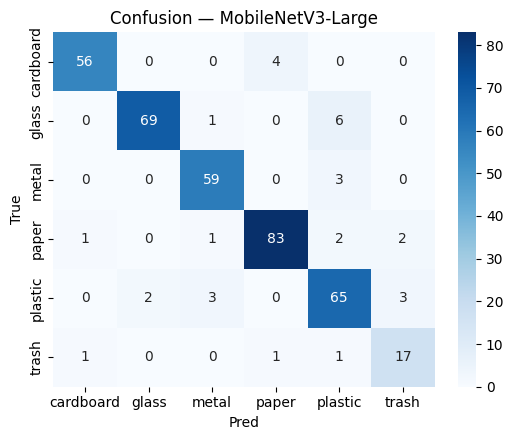

In [20]:
# MobileNet-V3

run_model("MobileNetV3-Large")


===== EfficientNet-Lite0 =====


model.safetensors: reconstructing file:   0%|          |  0.00B / 18.8MB            

model.safetensors: downloading bytes:           |  0.00B            

  weights: tf_efficientnet_lite0
    epoch 01/12  val_f1=0.7457
    epoch 02/12  val_f1=0.8262
    epoch 03/12  val_f1=0.8300
    epoch 04/12  val_f1=0.8572
    epoch 05/12  val_f1=0.8949
    epoch 06/12  val_f1=0.8759
    epoch 07/12  val_f1=0.8798
    epoch 08/12  val_f1=0.9000
    epoch 09/12  val_f1=0.9070
    epoch 10/12  val_f1=0.9025
    epoch 11/12  val_f1=0.9105
    epoch 12/12  val_f1=0.9192
  TEST acc=0.8947 f1=0.8802 auc=0.9911 | 13.77MB 0.745GFLOPs 32.26ms 31.0fps
              precision    recall  f1-score   support

   cardboard       1.00      0.95      0.97        60
       glass       0.89      0.92      0.90        76
       metal       0.89      0.87      0.88        62
       paper       0.95      0.88      0.91        89
     plastic       0.86      0.86      0.86        73
       trash       0.64      0.90      0.75        20

    accuracy                           0.89       380
   macro avg       0.87      0.90      0.88       380
weighted avg       0.90      0

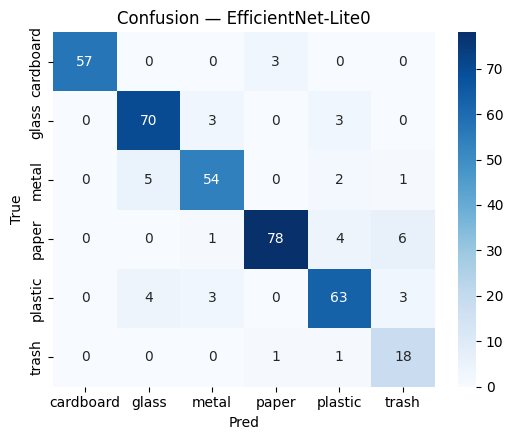

In [21]:
run_model("EfficientNet-Lite0")


===== ShuffleNetV2 =====
Downloading: "https://download.pytorch.org/models/shufflenetv2_x1-5666bf0f80.pth" to /root/.cache/torch/hub/checkpoints/shufflenetv2_x1-5666bf0f80.pth


100%|██████████| 8.79M/8.79M [00:00<00:00, 55.2MB/s]


  weights: shufflenet_v2_x1_0
    epoch 01/12  val_f1=0.6235
    epoch 02/12  val_f1=0.7428
    epoch 03/12  val_f1=0.8126
    epoch 04/12  val_f1=0.8656
    epoch 05/12  val_f1=0.8736
    epoch 06/12  val_f1=0.9038
    epoch 07/12  val_f1=0.8915
    epoch 08/12  val_f1=0.9061
    epoch 09/12  val_f1=0.8917
    epoch 10/12  val_f1=0.8996
    epoch 11/12  val_f1=0.8994
    epoch 12/12  val_f1=0.8944
    early stop @ 12
  TEST acc=0.9026 f1=0.8945 auc=0.9878 | 5.2MB 0.303GFLOPs 18.99ms 52.7fps
              precision    recall  f1-score   support

   cardboard       0.95      0.93      0.94        60
       glass       0.86      0.96      0.91        76
       metal       0.87      0.85      0.86        62
       paper       0.91      0.92      0.92        89
     plastic       0.98      0.84      0.90        73
       trash       0.78      0.90      0.84        20

    accuracy                           0.90       380
   macro avg       0.89      0.90      0.89       380
weighted avg   

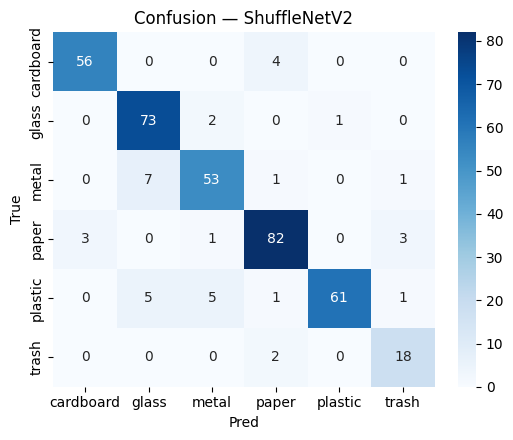

In [22]:
run_model("ShuffleNetV2")


===== GhostNet =====


model.safetensors: reconstructing file:   0%|          |  0.00B / 20.9MB            

model.safetensors: downloading bytes:           |  0.00B            

  weights: ghostnet_100
    epoch 01/12  val_f1=0.7728
    epoch 02/12  val_f1=0.8696
    epoch 03/12  val_f1=0.8999
    epoch 04/12  val_f1=0.8853
    epoch 05/12  val_f1=0.8710
    epoch 06/12  val_f1=0.8982
    epoch 07/12  val_f1=0.9045
    epoch 08/12  val_f1=0.9150
    epoch 09/12  val_f1=0.9300
    epoch 10/12  val_f1=0.9204
    epoch 11/12  val_f1=0.9114
    epoch 12/12  val_f1=0.9071
  TEST acc=0.9263 f1=0.9165 auc=0.9933 | 15.88MB 0.304GFLOPs 29.73ms 33.6fps
              precision    recall  f1-score   support

   cardboard       0.98      0.93      0.96        60
       glass       0.92      0.95      0.94        76
       metal       0.91      0.95      0.93        62
       paper       0.93      0.93      0.93        89
     plastic       0.94      0.88      0.91        73
       trash       0.78      0.90      0.84        20

    accuracy                           0.93       380
   macro avg       0.91      0.92      0.92       380
weighted avg       0.93      0.93      

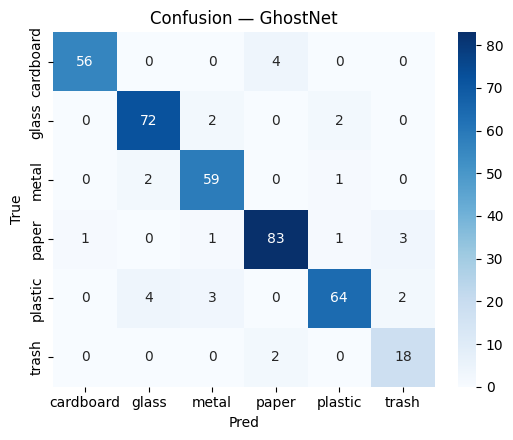

In [23]:
run_model("GhostNet")


===== SqueezeNet =====
Downloading: "https://download.pytorch.org/models/squeezenet1_1-b8a52dc0.pth" to /root/.cache/torch/hub/checkpoints/squeezenet1_1-b8a52dc0.pth


100%|██████████| 4.73M/4.73M [00:00<00:00, 177MB/s]

  weights: squeezenet1_1


    epoch 01/12  val_f1=0.6422
    epoch 02/12  val_f1=0.7018
    epoch 03/12  val_f1=0.7304
    epoch 04/12  val_f1=0.6709
    epoch 05/12  val_f1=0.7849
    epoch 06/12  val_f1=0.7826
    epoch 07/12  val_f1=0.8401
    epoch 08/12  val_f1=0.8081
    epoch 09/12  val_f1=0.8391
    epoch 10/12  val_f1=0.8422
    epoch 11/12  val_f1=0.8446
    epoch 12/12  val_f1=0.8400
  TEST acc=0.8579 f1=0.8368 auc=0.9836 | 2.92MB 0.546GFLOPs 23.71ms 42.2fps
              precision    recall  f1-score   support

   cardboard       0.96      0.92      0.94        60
       glass       0.84      0.89      0.87        76
       metal       0.88      0.79      0.83        62
       paper       0.91      0.82      0.86        89
     plastic       0.84      0.89      0.87        73
       trash       0.55      0.80      0.65        20

    accuracy                           0.86       380
   macro avg       0.83      0.85      0.84       380
weighted avg       0.87      0.86      0.86       380



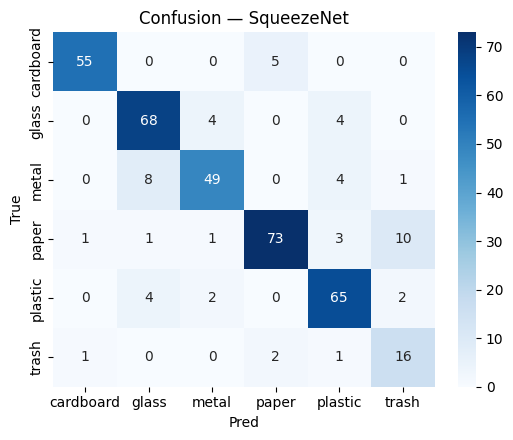

In [24]:
run_model("SqueezeNet")


===== EfficientViT =====


model.safetensors: reconstructing file:   0%|          |  0.00B / 13.7MB            

model.safetensors: downloading bytes:           |  0.00B            

  weights: efficientvit_b0
    epoch 01/12  val_f1=0.4516
    epoch 02/12  val_f1=0.4707
    epoch 03/12  val_f1=0.6050
    epoch 04/12  val_f1=0.5753
    epoch 05/12  val_f1=0.8825
    epoch 06/12  val_f1=0.9066
    epoch 07/12  val_f1=0.8948
    epoch 08/12  val_f1=0.9160
    epoch 09/12  val_f1=0.9313
    epoch 10/12  val_f1=0.9269
    epoch 11/12  val_f1=0.9412
    epoch 12/12  val_f1=0.9431
  TEST acc=0.9342 f1=0.9263 auc=0.9935 | 8.64MB 0.202GFLOPs 17.02ms 58.8fps
              precision    recall  f1-score   support

   cardboard       0.97      0.95      0.96        60
       glass       0.93      0.93      0.93        76
       metal       0.91      0.95      0.93        62
       paper       0.96      0.92      0.94        89
     plastic       0.94      0.92      0.93        73
       trash       0.79      0.95      0.86        20

    accuracy                           0.93       380
   macro avg       0.92      0.94      0.93       380
weighted avg       0.94      0.93    

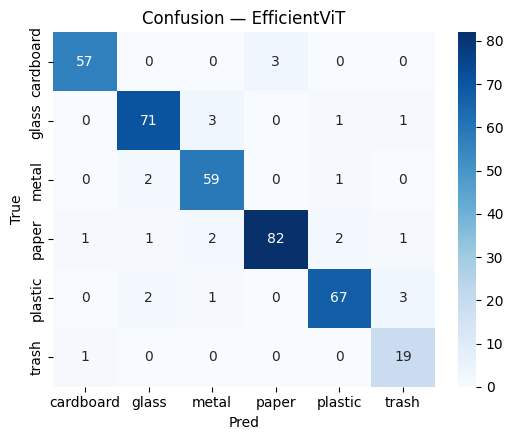

In [25]:
run_model("EfficientViT")

In [26]:
# Assemble comparison table (all metrics + efficiency)

metric_cols = ["accuracy", "precision", "recall", "f1", "roc_auc",
               "params_M", "gflops", "size_MB", "cpu_ms", "cpu_ms_p95", "fps", "gpu_mem_MB"]
df = pd.DataFrame({m: {k: RESULTS[m][k] for k in metric_cols} for m in RESULTS}).T
df = df.sort_values("f1", ascending=False)
df.to_csv("/content/model_comparison.csv")

display(df.round(4))

,accuracy,precision,recall,f1,roc_auc,params_M,gflops,size_MB,cpu_ms,cpu_ms_p95,fps,gpu_mem_MB
EfficientViT,0.9342,0.9180,0.9375,0.9263,0.9935,2.137,0.202,8.64,17.02,18.67,58.8,39.1
GhostNet,0.9263,0.9116,0.9236,0.9165,0.9933,3.909,0.304,15.88,29.73,33.92,33.6,56.3
MobileNetV3-Large,0.9184,0.9032,0.9110,0.9064,0.9918,4.210,0.440,17.03,22.31,25.51,44.8,60.3
ShuffleNetV2,0.9026,0.8924,0.9009,0.8945,0.9878,1.260,0.303,5.20,18.99,24.45,52.7,30.4
EfficientNet-Lite0,0.8947,0.8714,0.8969,0.8802,0.9911,3.379,0.745,13.77,32.26,36.49,31.0,59.7
SqueezeNet,0.8579,0.8313,0.8521,0.8368,0.9836,0.726,0.546,2.92,23.71,26.50,42.2,29.7


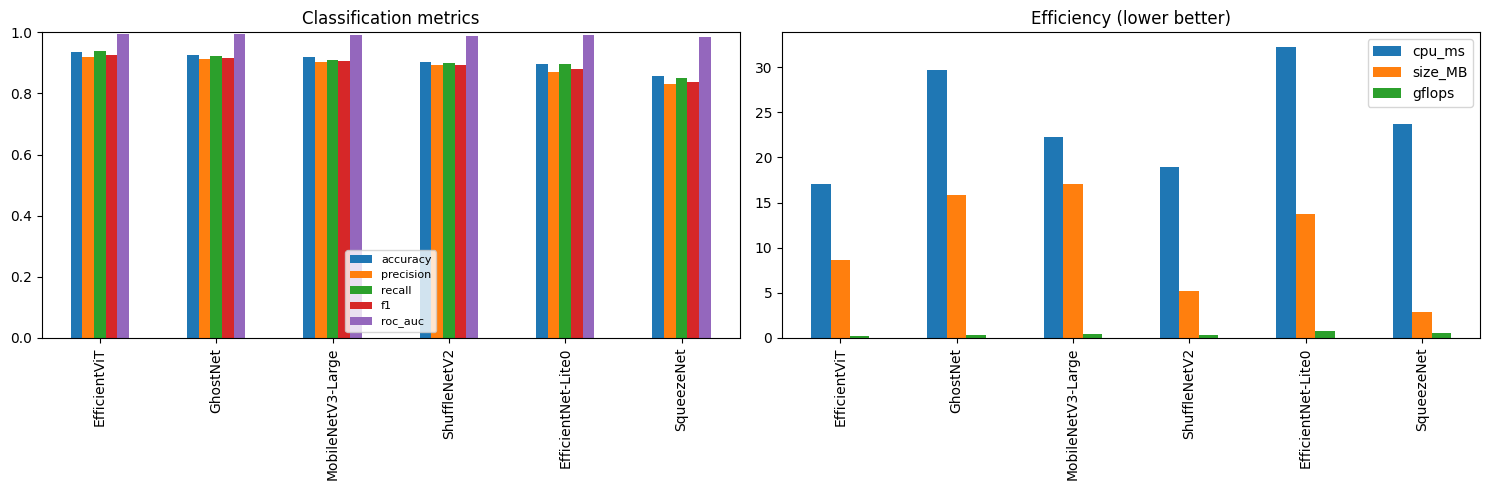

In [27]:
# Metric bar charts

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
df[["accuracy", "precision", "recall", "f1", "roc_auc"]].plot.bar(ax=axes[0])
axes[0].set_title("Classification metrics"); axes[0].set_ylim(0, 1); axes[0].legend(fontsize=8)
df[["cpu_ms", "size_MB", "gflops"]].plot.bar(ax=axes[1]); axes[1].set_title("Efficiency (lower better)")
plt.tight_layout(); plt.show()

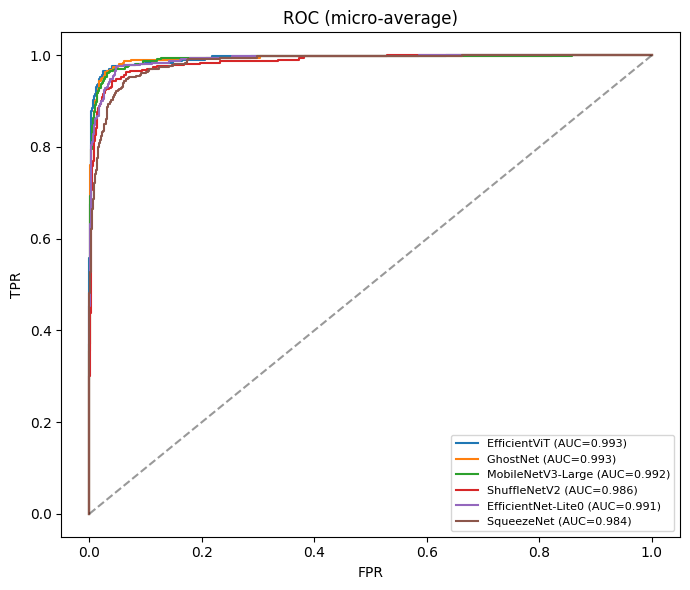

In [28]:
# ROC curves (micro-average, one per model)

plt.figure(figsize=(7, 6))
yb = label_binarize(TEST_TRUE, classes=list(range(NUM_CLASSES)))
for name in df.index:
    fpr, tpr, _ = roc_curve(yb.ravel(), RESULTS[name]["probs"].ravel())
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc(fpr, tpr):.3f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.4); plt.xlabel("FPR"); plt.ylabel("TPR")
plt.title("ROC (micro-average)"); plt.legend(fontsize=8); plt.tight_layout(); plt.show()

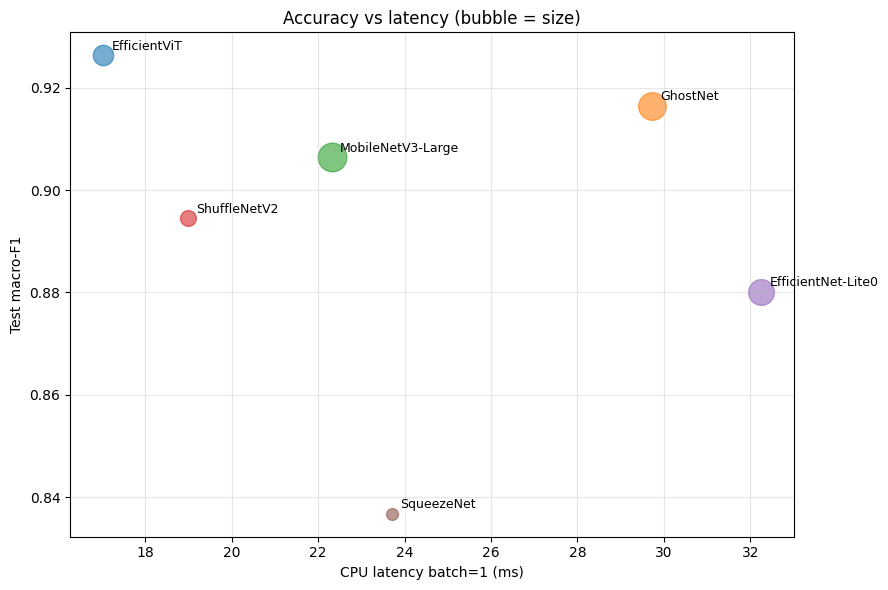

In [29]:
# Accuracy vs latency trade-off (bubble = size) — the key figure

plt.figure(figsize=(9, 6))
for name in df.index:
    r = df.loc[name]
    plt.scatter(r["cpu_ms"], r["f1"], s=max(r["size_MB"], 1) * 25, alpha=0.6)
    plt.annotate(name, (r["cpu_ms"], r["f1"]), xytext=(6, 4), textcoords="offset points", fontsize=9)
plt.xlabel("CPU latency batch=1 (ms)"); plt.ylabel("Test macro-F1")
plt.title("Accuracy vs latency (bubble = size)"); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

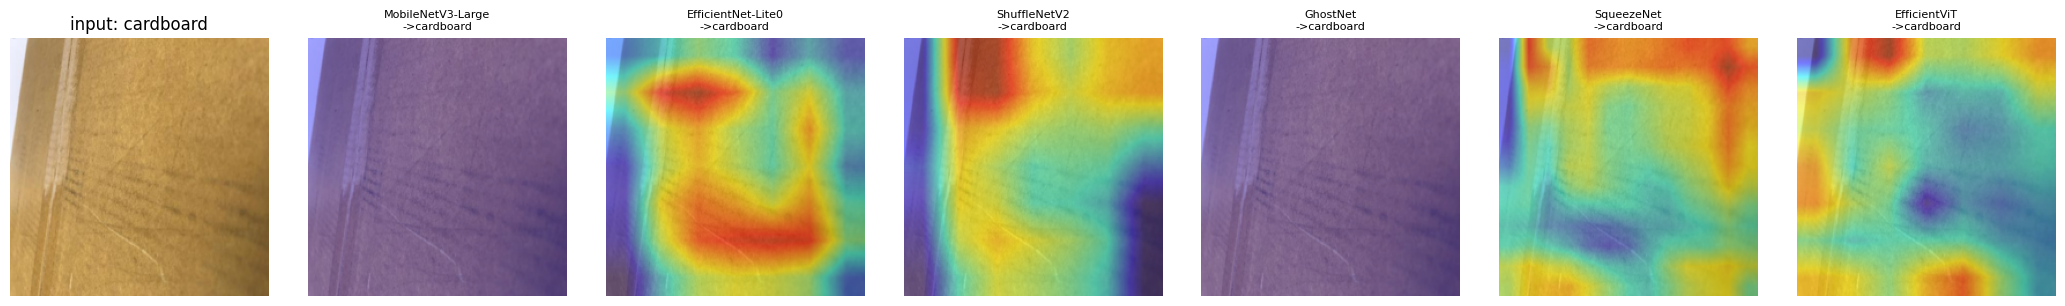

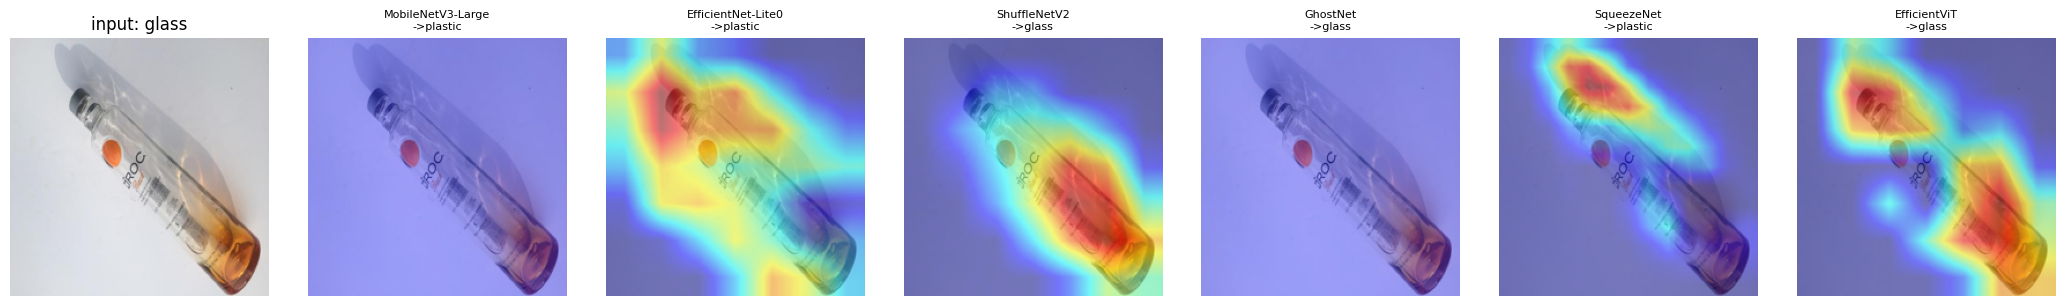

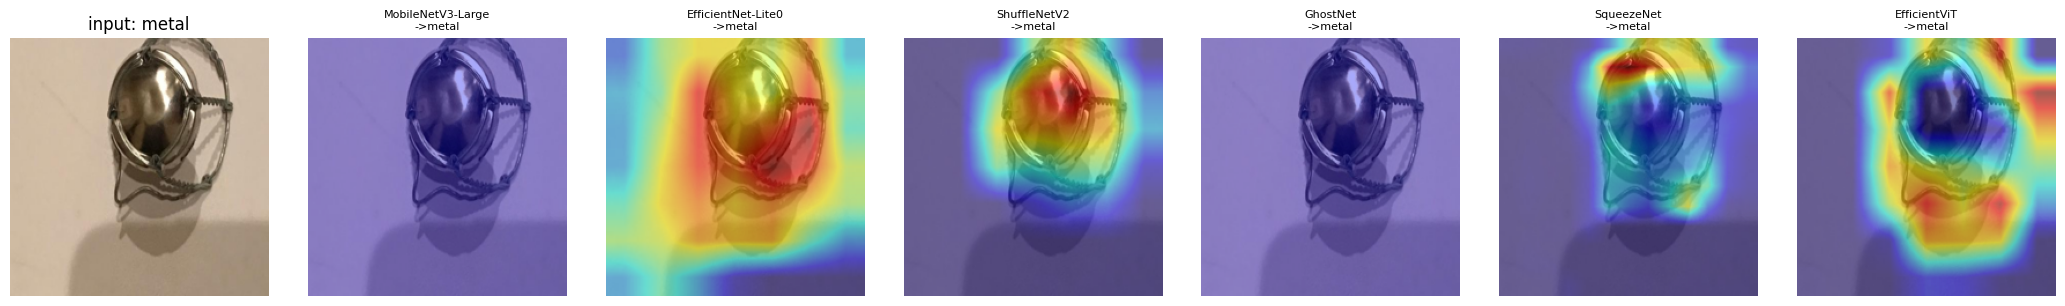

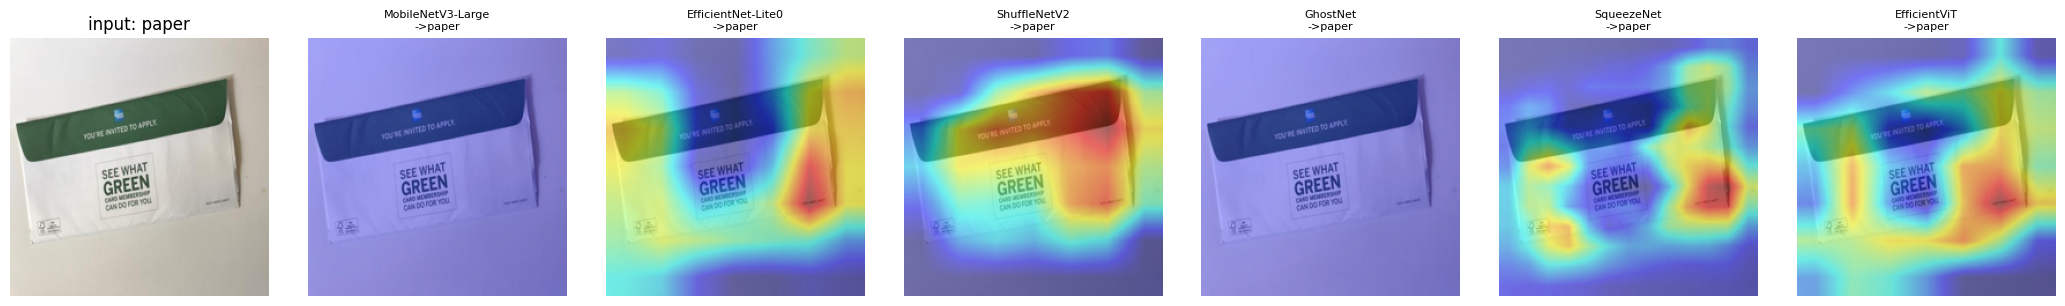

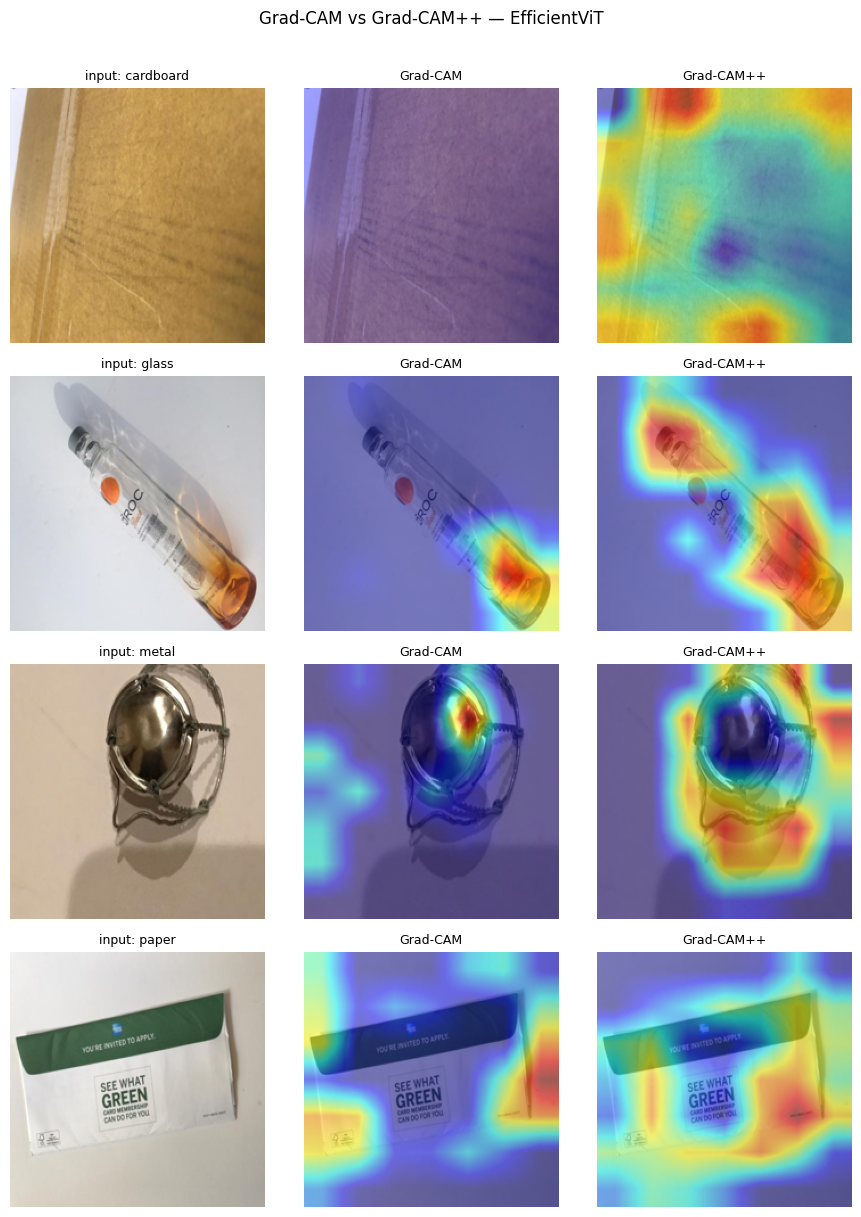

In [30]:
# Grad-CAM & Grad-CAM++

sample_specs = []
for c in CLASSES[:4]:
    d = os.path.join(SPLIT_ROOT, "test", c)
    f = next(f for f in os.listdir(d) if f.lower().endswith(IMG_EXT))
    sample_specs.append((c, os.path.join(d, f)))

for cls, path in sample_specs:
    rgb, tensor = to_input(path)
    fig, axes = plt.subplots(1, len(RESULTS) + 1, figsize=(3 * (len(RESULTS) + 1), 3))
    axes[0].imshow(rgb); axes[0].set_title(f"input: {cls}"); axes[0].axis("off")
    for ax, name in zip(axes[1:], RESULTS.keys()):
        m = load_trained(name)
        with torch.inference_mode(): pred = int(m(tensor.to(DEVICE)).argmax(1))
        g = GradCAMPlusPlus(model=m, target_layers=[last_conv_layer(m)])(
                input_tensor=tensor.to(DEVICE), targets=[ClassifierOutputTarget(pred)])[0]
        ax.imshow(show_cam_on_image(rgb, g, use_rgb=True))
        ax.set_title(f"{name}\n->{CLASSES[pred]}", fontsize=8); ax.axis("off")
        del m
        if DEVICE == "cuda": torch.cuda.empty_cache()
    plt.tight_layout(); plt.show()

top = df.index[0]; m = load_trained(top)
fig, axes = plt.subplots(len(sample_specs), 3, figsize=(9, 3 * len(sample_specs)))
for row, (cls, path) in enumerate(sample_specs):
    rgb, tensor = to_input(path)
    with torch.inference_mode(): pred = int(m(tensor.to(DEVICE)).argmax(1))
    tgt = [ClassifierOutputTarget(pred)]
    gc   = GradCAM(model=m, target_layers=[last_conv_layer(m)])(input_tensor=tensor.to(DEVICE), targets=tgt)[0]
    gcpp = GradCAMPlusPlus(model=m, target_layers=[last_conv_layer(m)])(input_tensor=tensor.to(DEVICE), targets=tgt)[0]
    for ax, im, t in zip(axes[row], [rgb, show_cam_on_image(rgb, gc, use_rgb=True),
                                     show_cam_on_image(rgb, gcpp, use_rgb=True)],
                         [f"input: {cls}", "Grad-CAM", "Grad-CAM++"]):
        ax.imshow(im); ax.set_title(t, fontsize=9); ax.axis("off")
plt.suptitle(f"Grad-CAM vs Grad-CAM++ — {top}", y=1.01); plt.tight_layout(); plt.show()
del m

In [31]:
# Composite ranking: accuracy-focused, penalising latency and size (min-max normalised)

from statsmodels.stats.contingency_tables import mcnemar

rank = df.copy()
def norm(s): return (s - s.min()) / (s.max() - s.min() + 1e-9)
rank["composite"] = (0.55 * norm(rank["f1"]) + 0.15 * norm(rank["roc_auc"])
                     + 0.20 * (1 - norm(rank["cpu_ms"])) + 0.10 * (1 - norm(rank["size_MB"]))).round(4)
rank = rank.sort_values("composite", ascending=False)
display(rank[["f1", "roc_auc", "cpu_ms", "size_MB", "composite"]].round(4))
BEST = rank.index[0]

print("Top by composite:", BEST, "| Top by F1:", df.index[0])

,f1,roc_auc,cpu_ms,size_MB,composite
EfficientViT,0.9263,0.9935,17.02,8.64,0.9595
MobileNetV3-Large,0.9064,0.9918,22.31,17.03,0.6818
GhostNet,0.9165,0.9933,29.73,15.88,0.6771
ShuffleNetV2,0.8945,0.9878,18.99,5.20,0.6757
EfficientNet-Lite0,0.8802,0.9911,32.26,13.77,0.4028
SqueezeNet,0.8368,0.9836,23.71,2.92,0.2122


Top by composite: EfficientViT | Top by F1: EfficientViT


In [32]:
a, b = df.index[0], df.index[1]
pa = (RESULTS[a]["preds"] == TEST_TRUE); pb = (RESULTS[b]["preds"] == TEST_TRUE)
res = mcnemar([[int(np.sum(pa & pb)), int(np.sum(pa & ~pb))],
               [int(np.sum(~pa & pb)), int(np.sum(~pa & ~pb))]], exact=True)
print(f"McNemar {a} vs {b}: p={res.pvalue:.4f} ->",
      "significant" if res.pvalue < 0.05 else "NOT significant (gap may be noise)")

McNemar EfficientViT vs GhostNet: p=0.6776 -> NOT significant (gap may be noise)


In [33]:
# Fine-tune the best model

BEST_NAME = max(RESULTS, key=lambda k: RESULTS[k]["f1"])
print("Fine-tuning:", BEST_NAME)

def get_head(m):
    if hasattr(m, "get_classifier"):
        try: return m.get_classifier()
        except Exception: pass
    if hasattr(m, "fc"): return m.fc
    if hasattr(m, "classifier"): return m.classifier
    raise RuntimeError("head not found")

def run_stage(model, opt, epochs, patience, tag, best_f1, best_state):
    crit = nn.CrossEntropyLoss(weight=class_weights.to(DEVICE), label_smoothing=0.05)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    scaler = torch.amp.GradScaler("cuda", enabled=(DEVICE == "cuda"))
    wait = 0
    for ep in range(epochs):
        model.train()
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE); opt.zero_grad()
            with torch.autocast(device_type=("cuda" if DEVICE == "cuda" else "cpu"), enabled=(DEVICE == "cuda")):
                loss = crit(model(x), y)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
        sched.step()
        yv, pv, _ = _infer(model, val_loader); vf1 = f1_score(yv, pv, average="macro")
        print(f"  [{tag}] epoch {ep+1:02d}/{epochs}  val_f1={vf1:.4f}")
        if vf1 > best_f1:
            best_f1 = vf1
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience: print(f"  [{tag}] early stop @ {ep+1}"); break
    return best_f1, best_state

set_seed(SEED)
model = load_trained(BEST_NAME); best_f1, best_state = -1, None

for p in model.parameters(): p.requires_grad = False
for p in get_head(model).parameters(): p.requires_grad = True
opt1 = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=1e-3, weight_decay=1e-4)
best_f1, best_state = run_stage(model, opt1, 5, 3, "stage1", best_f1, best_state)

for p in model.parameters(): p.requires_grad = True
head_ids = {id(p) for p in get_head(model).parameters()}
opt2 = torch.optim.AdamW([
    {"params": [p for p in model.parameters() if id(p) not in head_ids], "lr": 2e-5},
    {"params": [p for p in model.parameters() if id(p) in head_ids],     "lr": 4e-4}], weight_decay=1e-4)
best_f1, best_state = run_stage(model, opt2, 25, 6, "stage2", best_f1, best_state)

model.load_state_dict(best_state)
FT_NAME = BEST_NAME + "-FT"
wpath = os.path.join(WEIGHTS_DIR, FT_NAME + ".pt"); torch.save(model.state_dict(), wpath)
metrics, prob, preds = evaluate_full(model, test_loader); eff = measure_efficiency(model)
RESULTS[FT_NAME] = {**metrics, **eff, "used": RESULTS[BEST_NAME]["used"],
                    "weights": wpath, "probs": prob, "preds": preds}
MODEL_REGISTRY[FT_NAME] = MODEL_REGISTRY[BEST_NAME]   # so load_trained works on the FT model
print(f"\n{FT_NAME}: acc={metrics['accuracy']:.4f} f1={metrics['f1']:.4f}")

cmp = pd.DataFrame({"before": {k: RESULTS[BEST_NAME][k] for k in ["accuracy","precision","recall","f1","roc_auc"]},
                    "after":  {k: RESULTS[FT_NAME][k]   for k in ["accuracy","precision","recall","f1","roc_auc"]}})
cmp["delta"] = cmp["after"] - cmp["before"]; display(cmp.round(4))
pc = pd.DataFrame({"before": f1_score(TEST_TRUE, RESULTS[BEST_NAME]["preds"], average=None, labels=range(NUM_CLASSES)),
                   "after":  f1_score(TEST_TRUE, RESULTS[FT_NAME]["preds"],   average=None, labels=range(NUM_CLASSES))},
                  index=CLASSES)
pc["delta"] = pc["after"] - pc["before"]; display(pc.round(3))

Fine-tuning: EfficientViT
  [stage1] epoch 01/5  val_f1=0.9238
  [stage1] epoch 02/5  val_f1=0.9237
  [stage1] epoch 03/5  val_f1=0.9235
  [stage1] epoch 04/5  val_f1=0.9278
  [stage1] epoch 05/5  val_f1=0.9298
  [stage2] epoch 01/25  val_f1=0.9285
  [stage2] epoch 02/25  val_f1=0.9138
  [stage2] epoch 03/25  val_f1=0.9368
  [stage2] epoch 04/25  val_f1=0.9228
  [stage2] epoch 05/25  val_f1=0.9398
  [stage2] epoch 06/25  val_f1=0.9334
  [stage2] epoch 07/25  val_f1=0.9312
  [stage2] epoch 08/25  val_f1=0.9272
  [stage2] epoch 09/25  val_f1=0.9319
  [stage2] epoch 10/25  val_f1=0.9225
  [stage2] epoch 11/25  val_f1=0.9251
  [stage2] early stop @ 11

EfficientViT-FT: acc=0.9342 f1=0.9241


,before,after,delta
accuracy,0.9342,0.9342,0.0000
precision,0.9180,0.9150,-0.0030
recall,0.9375,0.9375,0.0000
f1,0.9263,0.9241,-0.0022
roc_auc,0.9935,0.9925,-0.0010


,before,after,delta
cardboard,0.958,0.958,0.000
glass,0.934,0.934,0.000
metal,0.929,0.922,-0.007
paper,0.943,0.943,0.000
plastic,0.931,0.944,0.013
trash,0.864,0.844,-0.019


CV pool: 2147 | held-out test: 380

===== MobileNetV3-Large =====
  fold 1/5: val_f1=0.8850 test_f1=0.9073
  fold 2/5: val_f1=0.9068 test_f1=0.8940
  fold 3/5: val_f1=0.9101 test_f1=0.8749
  fold 4/5: val_f1=0.9110 test_f1=0.9166
  fold 5/5: val_f1=0.9145 test_f1=0.8882
  -> test_f1 0.8962 +/- 0.0146

===== EfficientNet-Lite0 =====
  fold 1/5: val_f1=0.8732 test_f1=0.8983
  fold 2/5: val_f1=0.8768 test_f1=0.8594
  fold 3/5: val_f1=0.8786 test_f1=0.8529
  fold 4/5: val_f1=0.8794 test_f1=0.8903
  fold 5/5: val_f1=0.9062 test_f1=0.8685
  -> test_f1 0.8739 +/- 0.0176

===== ShuffleNetV2 =====
  fold 1/5: val_f1=0.8793 test_f1=0.8971
  fold 2/5: val_f1=0.9063 test_f1=0.8903
  fold 3/5: val_f1=0.8802 test_f1=0.8826
  fold 4/5: val_f1=0.9192 test_f1=0.8653
  fold 5/5: val_f1=0.9231 test_f1=0.8752
  -> test_f1 0.8821 +/- 0.0112

===== GhostNet =====
  fold 1/5: val_f1=0.8829 test_f1=0.9206
  fold 2/5: val_f1=0.8988 test_f1=0.9010
  fold 3/5: val_f1=0.9016 test_f1=0.9205
  fold 4/5: val_f1=0.90

,val_f1_mean,val_f1_std,test_f1_mean,test_f1_std,test_acc_mean,test_acc_std
EfficientViT,0.9253,0.0168,0.9139,0.0132,0.9253,0.0111
GhostNet,0.9042,0.0151,0.9096,0.0104,0.9226,0.0061
MobileNetV3-Large,0.9055,0.0105,0.8962,0.0146,0.9079,0.0144
ShuffleNetV2,0.9016,0.0187,0.8821,0.0112,0.8932,0.0132
EfficientNet-Lite0,0.8828,0.0119,0.8739,0.0176,0.8879,0.0173
SqueezeNet,0.8464,0.0291,0.8442,0.0125,0.8568,0.0157


  EfficientViT         0.914 +/- 0.013
  GhostNet             0.910 +/- 0.010
  MobileNetV3-Large    0.896 +/- 0.015
  ShuffleNetV2         0.882 +/- 0.011
  EfficientNet-Lite0   0.874 +/- 0.018
  SqueezeNet           0.844 +/- 0.012

EfficientViT vs GhostNet: paired t-test p=0.4684


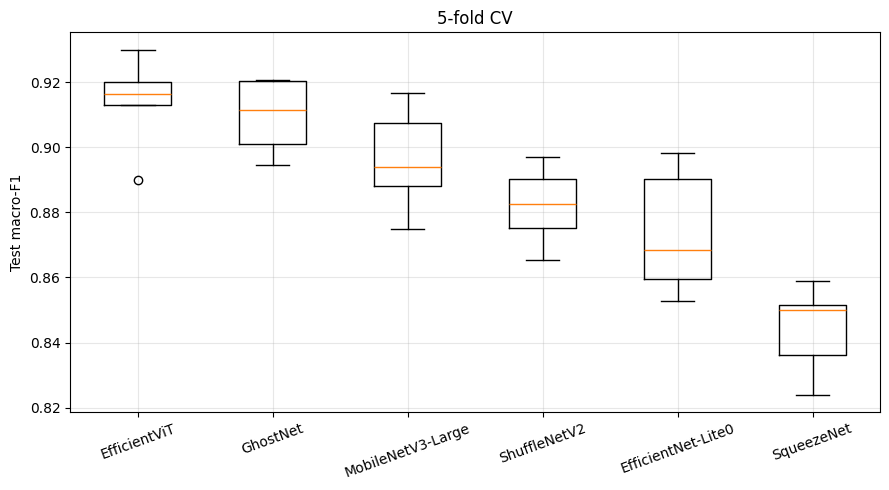

In [34]:
# K-fold cross-validation

from scipy.stats import ttest_rel, wilcoxon
K, CV_EPOCHS, CV_PATIENCE = 5, 12, 4
MODELS_FOR_CV = list(MODEL_REGISTRY.keys())[:6]   # trim to cut runtime

class PathDataset(Dataset):
    def __init__(self, paths, labels, tf): self.paths, self.labels, self.tf = paths, labels, tf
    def __len__(self): return len(self.paths)
    def __getitem__(self, i): return self.tf(Image.open(self.paths[i]).convert("RGB")), self.labels[i]

cv_paths, cv_labels = [], []
for split in ["train", "val"]:
    for ci, c in enumerate(CLASSES):
        d = os.path.join(SPLIT_ROOT, split, c)
        for f in os.listdir(d):
            if f.lower().endswith(IMG_EXT): cv_paths.append(os.path.join(d, f)); cv_labels.append(ci)
cv_paths, cv_labels = np.array(cv_paths), np.array(cv_labels)
print(f"CV pool: {len(cv_paths)} | held-out test: {len(TEST_TRUE)}")

def train_on_loaders(model, tr_ld, va_ld, weights, epochs, patience):
    model = model.to(DEVICE)
    crit = nn.CrossEntropyLoss(weight=weights.to(DEVICE))
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    scaler = torch.amp.GradScaler("cuda", enabled=(DEVICE == "cuda"))
    best_f1, best_state, wait = -1, None, 0
    for ep in range(epochs):
        model.train()
        for x, y in tr_ld:
            x, y = x.to(DEVICE), y.to(DEVICE); opt.zero_grad()
            with torch.autocast(device_type=("cuda" if DEVICE == "cuda" else "cpu"), enabled=(DEVICE == "cuda")):
                loss = crit(model(x), y)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
        sched.step()
        yv, pv, _ = _infer(model, va_ld); vf1 = f1_score(yv, pv, average="macro")
        if vf1 > best_f1:
            best_f1 = vf1
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience: break
    model.load_state_dict(best_state); return model, best_f1

skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=SEED)
CV = {}
for name in MODELS_FOR_CV:
    print(f"\n===== {name} =====")
    CV[name] = {"val_f1": [], "test_f1": [], "test_acc": []}
    for fold, (tr_idx, va_idx) in enumerate(skf.split(cv_paths, cv_labels), 1):
        set_seed(SEED + fold)
        tr_ld = DataLoader(PathDataset(cv_paths[tr_idx], cv_labels[tr_idx], train_tf),
                           BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
        va_ld = DataLoader(PathDataset(cv_paths[va_idx], cv_labels[va_idx], eval_tf),
                           BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
        c = np.bincount(cv_labels[tr_idx], minlength=NUM_CLASSES).astype(float)
        w = torch.tensor(c.sum() / (NUM_CLASSES * c), dtype=torch.float32)
        m, _ = build_model(MODEL_REGISTRY[name], NUM_CLASSES)
        m, vf1 = train_on_loaders(m, tr_ld, va_ld, w, CV_EPOCHS, CV_PATIENCE)
        mt, _, _ = evaluate_full(m, test_loader)
        CV[name]["val_f1"].append(vf1); CV[name]["test_f1"].append(mt["f1"]); CV[name]["test_acc"].append(mt["accuracy"])
        print(f"  fold {fold}/{K}: val_f1={vf1:.4f} test_f1={mt['f1']:.4f}")
        del m
        if DEVICE == "cuda": torch.cuda.empty_cache()
    print(f"  -> test_f1 {np.mean(CV[name]['test_f1']):.4f} +/- {np.std(CV[name]['test_f1']):.4f}")

cv_df = pd.DataFrame({n: {"val_f1_mean": np.mean(v["val_f1"]), "val_f1_std": np.std(v["val_f1"]),
                          "test_f1_mean": np.mean(v["test_f1"]), "test_f1_std": np.std(v["test_f1"]),
                          "test_acc_mean": np.mean(v["test_acc"]), "test_acc_std": np.std(v["test_acc"])}
                      for n, v in CV.items()}).T.sort_values("test_f1_mean", ascending=False)
display(cv_df.round(4))
for n, r in cv_df.iterrows(): print(f"  {n:20s} {r['test_f1_mean']:.3f} +/- {r['test_f1_std']:.3f}")

a, b = cv_df.index[0], cv_df.index[1]
fa, fb = CV[a]["test_f1"], CV[b]["test_f1"]
print(f"\n{a} vs {b}: paired t-test p={ttest_rel(fa, fb).pvalue:.4f}")
plt.figure(figsize=(9, 5))
plt.boxplot([CV[n]["test_f1"] for n in cv_df.index], labels=list(cv_df.index))
plt.ylabel("Test macro-F1"); plt.title(f"{K}-fold CV"); plt.xticks(rotation=20)
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

In [35]:
# Background remove

from PIL import Image
from rembg import remove
import io

def remove_background(image_path):

    with open(image_path, "rb") as f:
        input_bytes = f.read()

    output_bytes = remove(input_bytes)

    img = Image.open(io.BytesIO(output_bytes)).convert("RGBA")

    alpha = img.getchannel("A")
    bbox = alpha.getbbox()

    if bbox:
        img = img.crop(bbox)

    background = Image.new("RGB", img.size, (255,255,255))
    background.paste(img, mask=img.split()[3])

    output_path = "photo_nobg.jpg"
    background.save(output_path)

    return output_path

In [36]:
from rembg import remove
from PIL import Image
import io

def remove_background(image_path):

    with open(image_path, "rb") as f:
        input_bytes = f.read()

    output_bytes = remove(input_bytes)

    img = Image.open(io.BytesIO(output_bytes)).convert("RGBA")

    alpha = img.getchannel("A")
    bbox = alpha.getbbox()

    if bbox:
        img = img.crop(bbox)

    background = Image.new("RGB", img.size, (255,255,255))
    background.paste(img, mask=img.getchannel("A"))

    return background

Saving WhatsApp Image 2026-09-16 at 12.45.12 AM.jpeg to WhatsApp Image 2026-09-16 at 12.45.12 AM (1).jpeg
Uploaded image: WhatsApp Image 2026-09-16 at 12.45.12 AM (1).jpeg
Using model: EfficientViT

Prediction:
plastic (75.3%)

Class probabilities:
  plastic       75.3%
  paper         13.7%
  cardboard      5.2%
  metal          3.9%
  glass          0.9%
  trash          0.9%


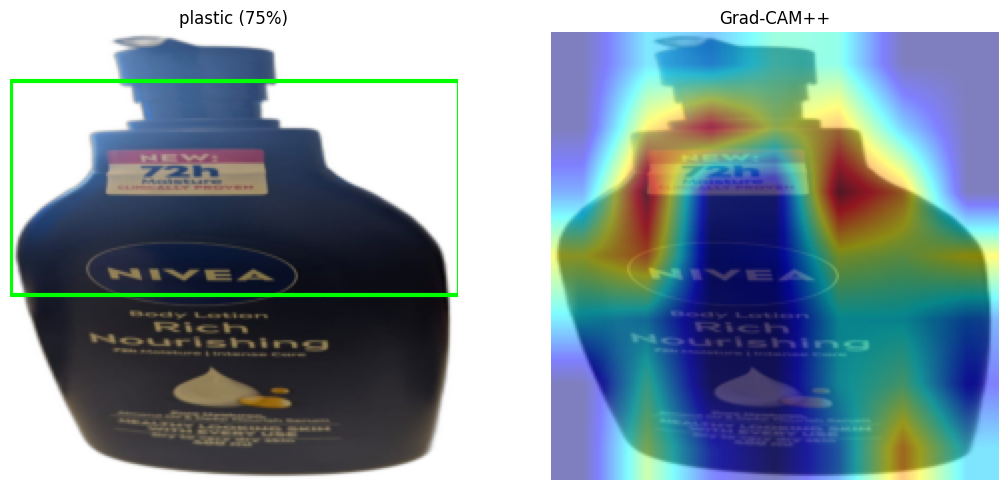

In [39]:
# Predict uploaded image + CAM localization

import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from google.colab import files
from PIL import Image
import torch
import torch.nn.functional as F

# ---------------------------------------------------------
# 1. Upload image from your device
# ---------------------------------------------------------

uploaded = files.upload()

# Get uploaded filename
capture_img = next(iter(uploaded.keys()))

print("Uploaded image:", capture_img)


# ---------------------------------------------------------
# 2. Load the best-performing model
# ---------------------------------------------------------

PREDICT_WITH = max(
    RESULTS,
    key=lambda k: RESULTS[k]["f1"]
)

model = load_trained(PREDICT_WITH)

print("Using model:", PREDICT_WITH)


# ---------------------------------------------------------
# 3. Prepare image
# ---------------------------------------------------------

img = remove_background(capture_img)

x = eval_tf(img).unsqueeze(0).to(DEVICE)


# ---------------------------------------------------------
# 4. Prediction
# ---------------------------------------------------------

model.eval()

with torch.inference_mode():
    logits = model(x)
    probs = F.softmax(logits, dim=1)[0].cpu().numpy()

pred = int(probs.argmax())

print("\nPrediction:")
print(f"{CLASSES[pred]} ({probs[pred] * 100:.1f}%)")

print("\nClass probabilities:")

for c, p in sorted(
    zip(CLASSES, probs),
    key=lambda t: -t[1]
):
    print(f"  {c:12s} {p * 100:5.1f}%")


# ---------------------------------------------------------
# 5. Prepare image for Grad-CAM++
# ---------------------------------------------------------

tensor = eval_tf(img).unsqueeze(0).to(DEVICE)

rgb = np.array(
    img.resize(
        (224, 224),
        Image.Resampling.BILINEAR
    )
).astype(np.float32) / 255.0


# ---------------------------------------------------------
# 6. Generate Grad-CAM++
# ---------------------------------------------------------

heat = GradCAMPlusPlus(
    model=model,
    target_layers=[last_conv_layer(model)]
)(
    input_tensor=tensor,
    targets=[ClassifierOutputTarget(pred)]
)[0]


# ---------------------------------------------------------
# 7. Create localization mask
# ---------------------------------------------------------

mask = (
    heat >= 0.5 * heat.max()
).astype(np.uint8)

cnts, _ = cv2.findContours(
    mask,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)


# ---------------------------------------------------------
# 8. Display prediction + localization
# ---------------------------------------------------------

fig, ax = plt.subplots(
    1,
    2,
    figsize=(11, 5)
)


# Original image
ax[0].imshow(rgb)
ax[0].axis("off")

ax[0].set_title(
    f"{CLASSES[pred]} ({probs[pred] * 100:.0f}%)"
)


# Draw bounding box around most activated region
if cnts:
    x0, y0, w, h = cv2.boundingRect(
        max(cnts, key=cv2.contourArea)
    )

    ax[0].add_patch(
        Rectangle(
            (x0, y0),
            w,
            h,
            fill=False,
            edgecolor="lime",
            linewidth=3
        )
    )


# Grad-CAM++
ax[1].imshow(
    show_cam_on_image(
        rgb,
        heat,
        use_rgb=True
    )
)

ax[1].axis("off")
ax[1].set_title("Grad-CAM++")


plt.tight_layout()
plt.show()